In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "C:/Users/A/Desktop/IPL DATA ANALYSIS/IPL_Matches_2008_2022.csv"
matches = pd.read_csv(file_path)

file_path2 = "C:/Users/A/Desktop/IPL DATA ANALYSIS/IPL_Ball_by_Ball_2008_2022.csv"

deliveries = pd.read_csv(file_path2)

In [82]:
print(matches.shape)
print(deliveries.shape)

(950, 20)
(225954, 17)


In [85]:
print(matches.columns)
print(deliveries.columns)

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')
Index(['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler',
       'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run',
       'non_boundary', 'isWicketDelivery', 'player_out', 'kind',
       'fielders_involved', 'BattingTeam'],
      dtype='object')


In [87]:
print(matches.head(2))
print(deliveries.head(2))

        ID       City        Date Season  MatchNumber  \
0  1312200  Ahmedabad  2022-05-29   2022        Final   
1  1312199  Ahmedabad  2022-05-27   2022  Qualifier 2   

                         Team1             Team2  \
0             Rajasthan Royals    Gujarat Titans   
1  Royal Challengers Bangalore  Rajasthan Royals   

                              Venue        TossWinner TossDecision SuperOver  \
0  Narendra Modi Stadium, Ahmedabad  Rajasthan Royals          bat         N   
1  Narendra Modi Stadium, Ahmedabad  Rajasthan Royals        field         N   

        WinningTeam    WonBy  Margin method Player_of_Match  \
0    Gujarat Titans  Wickets     7.0    NaN       HH Pandya   
1  Rajasthan Royals  Wickets     7.0    NaN      JC Buttler   

                                        Team1Players  \
0  ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...   
1  ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...   

                                        Team2Players      Umpire1      

In [89]:
# Convert date column safely
if 'Date' in matches.columns:
    matches['Date'] = pd.to_datetime(matches['Date'], errors='coerce')

# Remove duplicates
matches = matches.drop_duplicates()

# Check missing values
print("Missing values in Matches:")
print(matches.isnull().sum())

# Fill missing winner with 'No Result'
if 'WinningTeam' in matches.columns:
    matches['WinningTeam'] = matches['WinningTeam'].fillna('No Result')

print("Matches cleaned successfully ")

Missing values in Matches:
ID                   0
City                51
Date                 0
Season               0
MatchNumber          0
Team1                0
Team2                0
Venue                0
TossWinner           0
TossDecision         0
SuperOver            4
WinningTeam          4
WonBy                0
Margin              18
method             931
Player_of_Match      4
Team1Players         0
Team2Players         0
Umpire1              0
Umpire2              0
dtype: int64
Matches cleaned successfully 


In [91]:
# Remove duplicates
deliveries = deliveries.drop_duplicates()

# Check missing values
print("Missing values in Deliveries:")
print(deliveries.isnull().sum())

# Replace null runs with 0
if 'batsman_run' in deliveries.columns:
    deliveries['batsman_run'] = deliveries['batsman_run'].fillna(0)

# Replace null wicket values with 0
if 'isWicketDelivery' in deliveries.columns:
    deliveries['isWicketDelivery'] = deliveries['isWicketDelivery'].fillna(0)

print("Deliveries cleaned successfully ")

Missing values in Deliveries:
ID                        0
innings                   0
overs                     0
ballnumber                0
batter                    0
bowler                    0
non-striker               0
extra_type           213905
batsman_run               0
extras_run                0
total_run                 0
non_boundary              0
isWicketDelivery          0
player_out           214803
kind                 214803
fielders_involved    217966
BattingTeam               0
dtype: int64
Deliveries cleaned successfully 


In [93]:
print("Matches Data Types:")
print(matches.dtypes)

print("\nDeliveries Data Types:")
print(deliveries.dtypes)

Matches Data Types:
ID                          int64
City                       object
Date               datetime64[ns]
Season                     object
MatchNumber                object
Team1                      object
Team2                      object
Venue                      object
TossWinner                 object
TossDecision               object
SuperOver                  object
WinningTeam                object
WonBy                      object
Margin                    float64
method                     object
Player_of_Match            object
Team1Players               object
Team2Players               object
Umpire1                    object
Umpire2                    object
dtype: object

Deliveries Data Types:
ID                    int64
innings               int64
overs                 int64
ballnumber            int64
batter               object
bowler               object
non-striker          object
extra_type           object
batsman_run           int64
extras_run

In [95]:
matches['Date'] = pd.to_datetime(matches['Date'])
matches = matches[matches['MatchNumber'] != 'Final']

final_count = matches[matches['MatchNumber'] == 'Final'].shape[0]
print("Final matches count:", final_count)

Final matches count: 0


In [97]:
ipl = matches.merge(deliveries, on='ID')
# ===== OUTPUT SECTION =====
print("Merged Dataset Created Successfully ")
print("--------------------------------------")

print("Shape of merged dataset:", ipl.shape)

print("\nColumns in merged dataset:")
print(ipl.columns)

Merged Dataset Created Successfully 
--------------------------------------
Shape of merged dataset: (222268, 36)

Columns in merged dataset:
Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2', 'innings', 'overs', 'ballnumber',
       'batter', 'bowler', 'non-striker', 'extra_type', 'batsman_run',
       'extras_run', 'total_run', 'non_boundary', 'isWicketDelivery',
       'player_out', 'kind', 'fielders_involved', 'BattingTeam'],
      dtype='object')


In [99]:
batsman_stats = deliveries.groupby('batter').agg({
    'batsman_run':'sum',
    'ballnumber':'count'
})

batsman_stats['strike_rate'] = (batsman_stats['batsman_run'] / batsman_stats['ballnumber']) * 100

batsman_stats.sort_values('strike_rate', ascending=False).head(10)

,batsman_run,ballnumber,strike_rate
batter,,,
PN Mankad,4,1,400.000000
B Stanlake,5,2,250.000000
Umar Gul,39,19,205.263158
RS Sodhi,4,2,200.000000
TH David,187,94,198.936170
Shahid Afridi,81,46,176.086957
TU Deshpande,21,12,175.000000
I Malhotra,7,4,175.000000
LJ Wright,106,63,168.253968


In [101]:
outs = deliveries[deliveries['isWicketDelivery'] == 1]
outs = outs.groupby('batter')['isWicketDelivery'].count()

batsman_stats['outs'] = outs
batsman_stats['average'] = batsman_stats['batsman_run'] / batsman_stats['outs']
filtered = batsman_stats[batsman_stats['batsman_run'] > 500]

print(filtered.sort_values(by='average', ascending=False).head(10))

                batsman_run  ballnumber  strike_rate   outs    average
batter                                                                
KL Rahul               3895        2933   132.799182   84.0  46.369048
HM Amla                 577         418   138.038278   13.0  44.384615
AB de Villiers         5181        3487   148.580442  125.0  41.448000
JP Duminy              2029        1680   120.773810   49.0  41.408163
DA Warner              5883        4313   136.401577  143.0  41.139860
AK Markram              527         400   131.750000   13.0  40.538462
LMP Simmons            1079         878   122.892938   27.0  39.962963
JC Buttler             2832        1955   144.859335   71.0  39.887324
ML Hayden              1107         839   131.942789   28.0  39.535714
CH Gayle               4997        3516   142.121729  128.0  39.039062


In [103]:
# 1️Group by bowler
bowler_stats = deliveries.groupby('bowler').agg(
    total_runs=('total_run', 'sum'),
    balls_bowled=('ballnumber', 'count')
).reset_index()

# 2️ Filter bowlers who bowled more than 300 balls
bowler_stats = bowler_stats[bowler_stats['balls_bowled'] > 300]

# 3️ Calculate Economy Rate
bowler_stats['economy'] = bowler_stats['total_runs'] / (bowler_stats['balls_bowled'] / 6)

# 4️ Sort by best economy
bowler_stats = bowler_stats.sort_values(by='economy')

# 5️ Show Top 10 Economical Bowlers
print("Top 10 Economical Bowlers (Min 300 Balls) ")
print(bowler_stats.head(10))



Top 10 Economical Bowlers (Min 300 Balls) 
               bowler  total_runs  balls_bowled   economy
355       Rashid Khan        2411          2232  6.481183
6            A Kumble        1089           983  6.646999
401         SP Narine        3907          3516  6.667235
136        GD McGrath         366           329  6.674772
242    M Muralitharan        1765          1581  6.698292
263            MM Ali         631           564  6.712766
166           J Yadav         421           374  6.754011
337  RE van der Merwe         515           455  6.791209
128          DW Steyn        2583          2282  6.791411
120        DL Vettori         894           785  6.833121


In [113]:
# 1️1 Filter Powerplay overs (1 to 6)
powerplay = deliveries[deliveries['overs'] <= 6]

# 2️ Total runs scored in powerplay per match
powerplay_runs = powerplay.groupby('ID')['total_run'].sum().reset_index()
powerplay_runs.rename(columns={'total_run': 'powerplay_runs'}, inplace=True)

#3 Merge with matches to get season & teams
powerplay_runs = powerplay_runs.merge(
    matches[['ID', 'Season', 'Team1', 'Team2']],on='ID',how='left'
)

# 4️ Show output
print("Powerplay Runs Per Match ")
print(powerplay_runs.head())


Powerplay Runs Per Match 
       ID  powerplay_runs   Season                        Team1  \
0  335982             101  2007/08  Royal Challengers Bangalore   
1  335983             131  2007/08              Kings XI Punjab   
2  335984             103  2007/08             Delhi Daredevils   
3  335985             100  2007/08               Mumbai Indians   
4  335986              78  2007/08        Kolkata Knight Riders   

                         Team2  
0        Kolkata Knight Riders  
1          Chennai Super Kings  
2             Rajasthan Royals  
3  Royal Challengers Bangalore  
4              Deccan Chargers  


In [121]:
death = deliveries[deliveries['overs'] >= 16]
death_runs = death.groupby('ID')['total_run'].sum()
# Death over runs per match
death = deliveries[deliveries['overs'] >= 16]
death_runs = death.groupby('ID')['total_run'].sum().reset_index()
death_runs.rename(columns={'total_run': 'death_over_runs'}, inplace=True)
print("Death Over Runs Per Match ")
print(death_runs.head())

Death Over Runs Per Match 
       ID  death_over_runs
0  335982               64
1  335983              102
2  335984               23
3  335985               87
4  335986               53


In [117]:
chasing_wins = matches[matches['WonBy'] == 'Wickets']
defending_wins = matches[matches['WonBy'] == 'Runs']

print("Chasing Win %:", len(chasing_wins)/len(matches)*100)
print("Defending Win %:", len(defending_wins)/len(matches)*100)

Chasing Win %: 53.79679144385027
Defending Win %: 44.27807486631016


In [123]:
toss_success = matches[matches['TossWinner'] == matches['WinningTeam']]
toss_win_percentage = len(toss_success)/len(matches)*100
print("Toss Win Match Win Percentage ")
print(round(toss_win_percentage, 2), "%")

Toss Win Match Win Percentage 
51.34 %


In [133]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

matches['team1_encoded'] = le.fit_transform(matches['Team1'])
matches['team2_encoded'] = le.fit_transform(matches['Team2'])
matches['winner_encoded'] = le.fit_transform(matches['WinningTeam'])

print("Encoded Columns Preview ")
print(matches[['Team1','team1_encoded',
               'Team2','team2_encoded',
               'WinningTeam','winner_encoded']].head())

Encoded Columns Preview 
                         Team1  team1_encoded                 Team2  \
1  Royal Challengers Bangalore             16      Rajasthan Royals   
2  Royal Challengers Bangalore             16  Lucknow Super Giants   
3             Rajasthan Royals             13        Gujarat Titans   
4          Sunrisers Hyderabad             17          Punjab Kings   
5               Delhi Capitals              2        Mumbai Indians   

   team2_encoded                  WinningTeam  winner_encoded  
1             13             Rajasthan Royals              14  
2              9  Royal Challengers Bangalore              17  
3              5               Gujarat Titans               5  
4             12                 Punjab Kings              13  
5             10               Mumbai Indians              10  


In [135]:
from sklearn.model_selection import train_test_split

X = matches[['team1_encoded','team2_encoded']]
y = matches['winner_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train-Test Split Completed ")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Train-Test Split Completed 
X_train shape: (748, 2)
X_test shape : (187, 2)
y_train shape: (748,)
y_test shape : (187,)


In [137]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.45989304812834225


In [139]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.48128342245989303


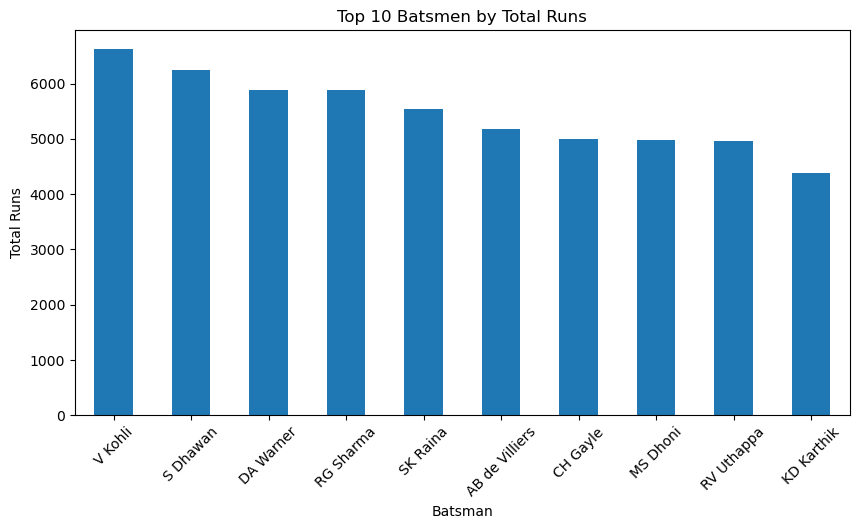

In [141]:
import matplotlib.pyplot as plt

top_batsmen = deliveries.groupby('batter')['batsman_run'].sum() \
                        .sort_values(ascending=False) \
                        .head(10)

plt.figure(figsize=(10,5))
top_batsmen.plot(kind='bar')
plt.title("Top 10 Batsmen by Total Runs")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()

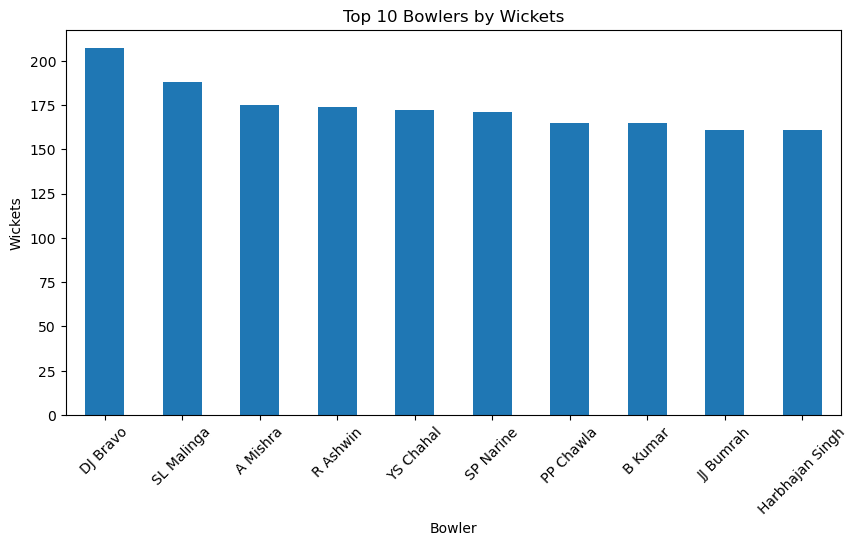

In [143]:
top_bowlers = deliveries[deliveries['isWicketDelivery'] == 1] \
                .groupby('bowler')['isWicketDelivery'] \
                .count() \
                .sort_values(ascending=False) \
                .head(10)

plt.figure(figsize=(10,5))
top_bowlers.plot(kind='bar')
plt.title("Top 10 Bowlers by Wickets")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45)
plt.show()

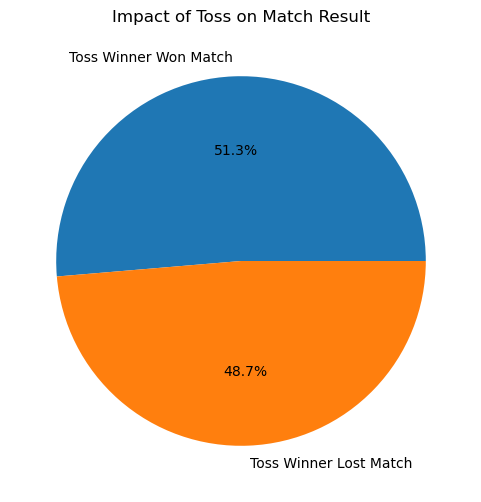

In [145]:
toss_success = matches[matches['TossWinner'] == matches['WinningTeam']]
toss_fail = matches[matches['TossWinner'] != matches['WinningTeam']]

data = [len(toss_success), len(toss_fail)]
labels = ['Toss Winner Won Match', 'Toss Winner Lost Match']

plt.figure(figsize=(6,6))
plt.pie(data, labels=labels, autopct='%1.1f%%')
plt.title("Impact of Toss on Match Result")
plt.show()

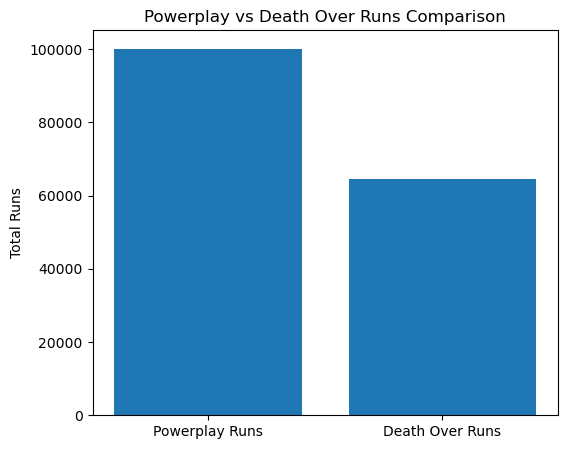

In [147]:
powerplay = deliveries[deliveries['overs'] <= 6]
death = deliveries[deliveries['overs'] >= 16]

pp_runs = powerplay['total_run'].sum()
death_runs = death['total_run'].sum()

labels = ['Powerplay Runs', 'Death Over Runs']
values = [pp_runs, death_runs]

plt.figure(figsize=(6,5))
plt.bar(labels, values)
plt.title("Powerplay vs Death Over Runs Comparison")
plt.ylabel("Total Runs")
plt.show()

Year-wise Total Runs in IPL 
    year  total_run
0   2008      17610
1   2009      16073
2   2010      18569
3   2011      20802
4   2012      22071
5   2013      22329
6   2014      18532
7   2015      17990
8   2016      18454
9   2017      18529
10  2018      19542
11  2019      19137
12  2020      19103
13  2021      18280
14  2022      24132


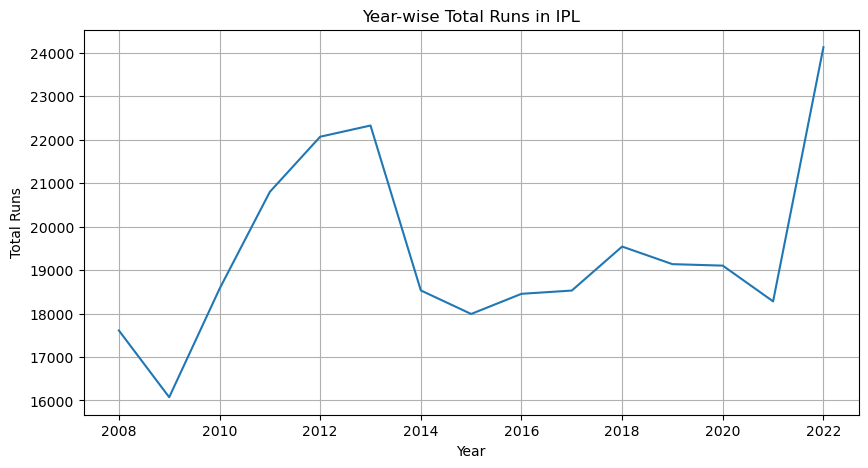

In [151]:
import matplotlib.pyplot as plt

# Extract year
ipl['year'] = pd.to_datetime(ipl['Date'], errors='coerce').dt.year

# Year-wise total runs
yearly_runs = ipl.groupby('year')['total_run'].sum().reset_index()

#  Print numerical output
print("Year-wise Total Runs in IPL ")
print(yearly_runs)

# 📊 Plot
plt.figure(figsize=(10,5))
plt.plot(yearly_runs['year'], yearly_runs['total_run'])
plt.title("Year-wise Total Runs in IPL")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.grid(True)
plt.show()

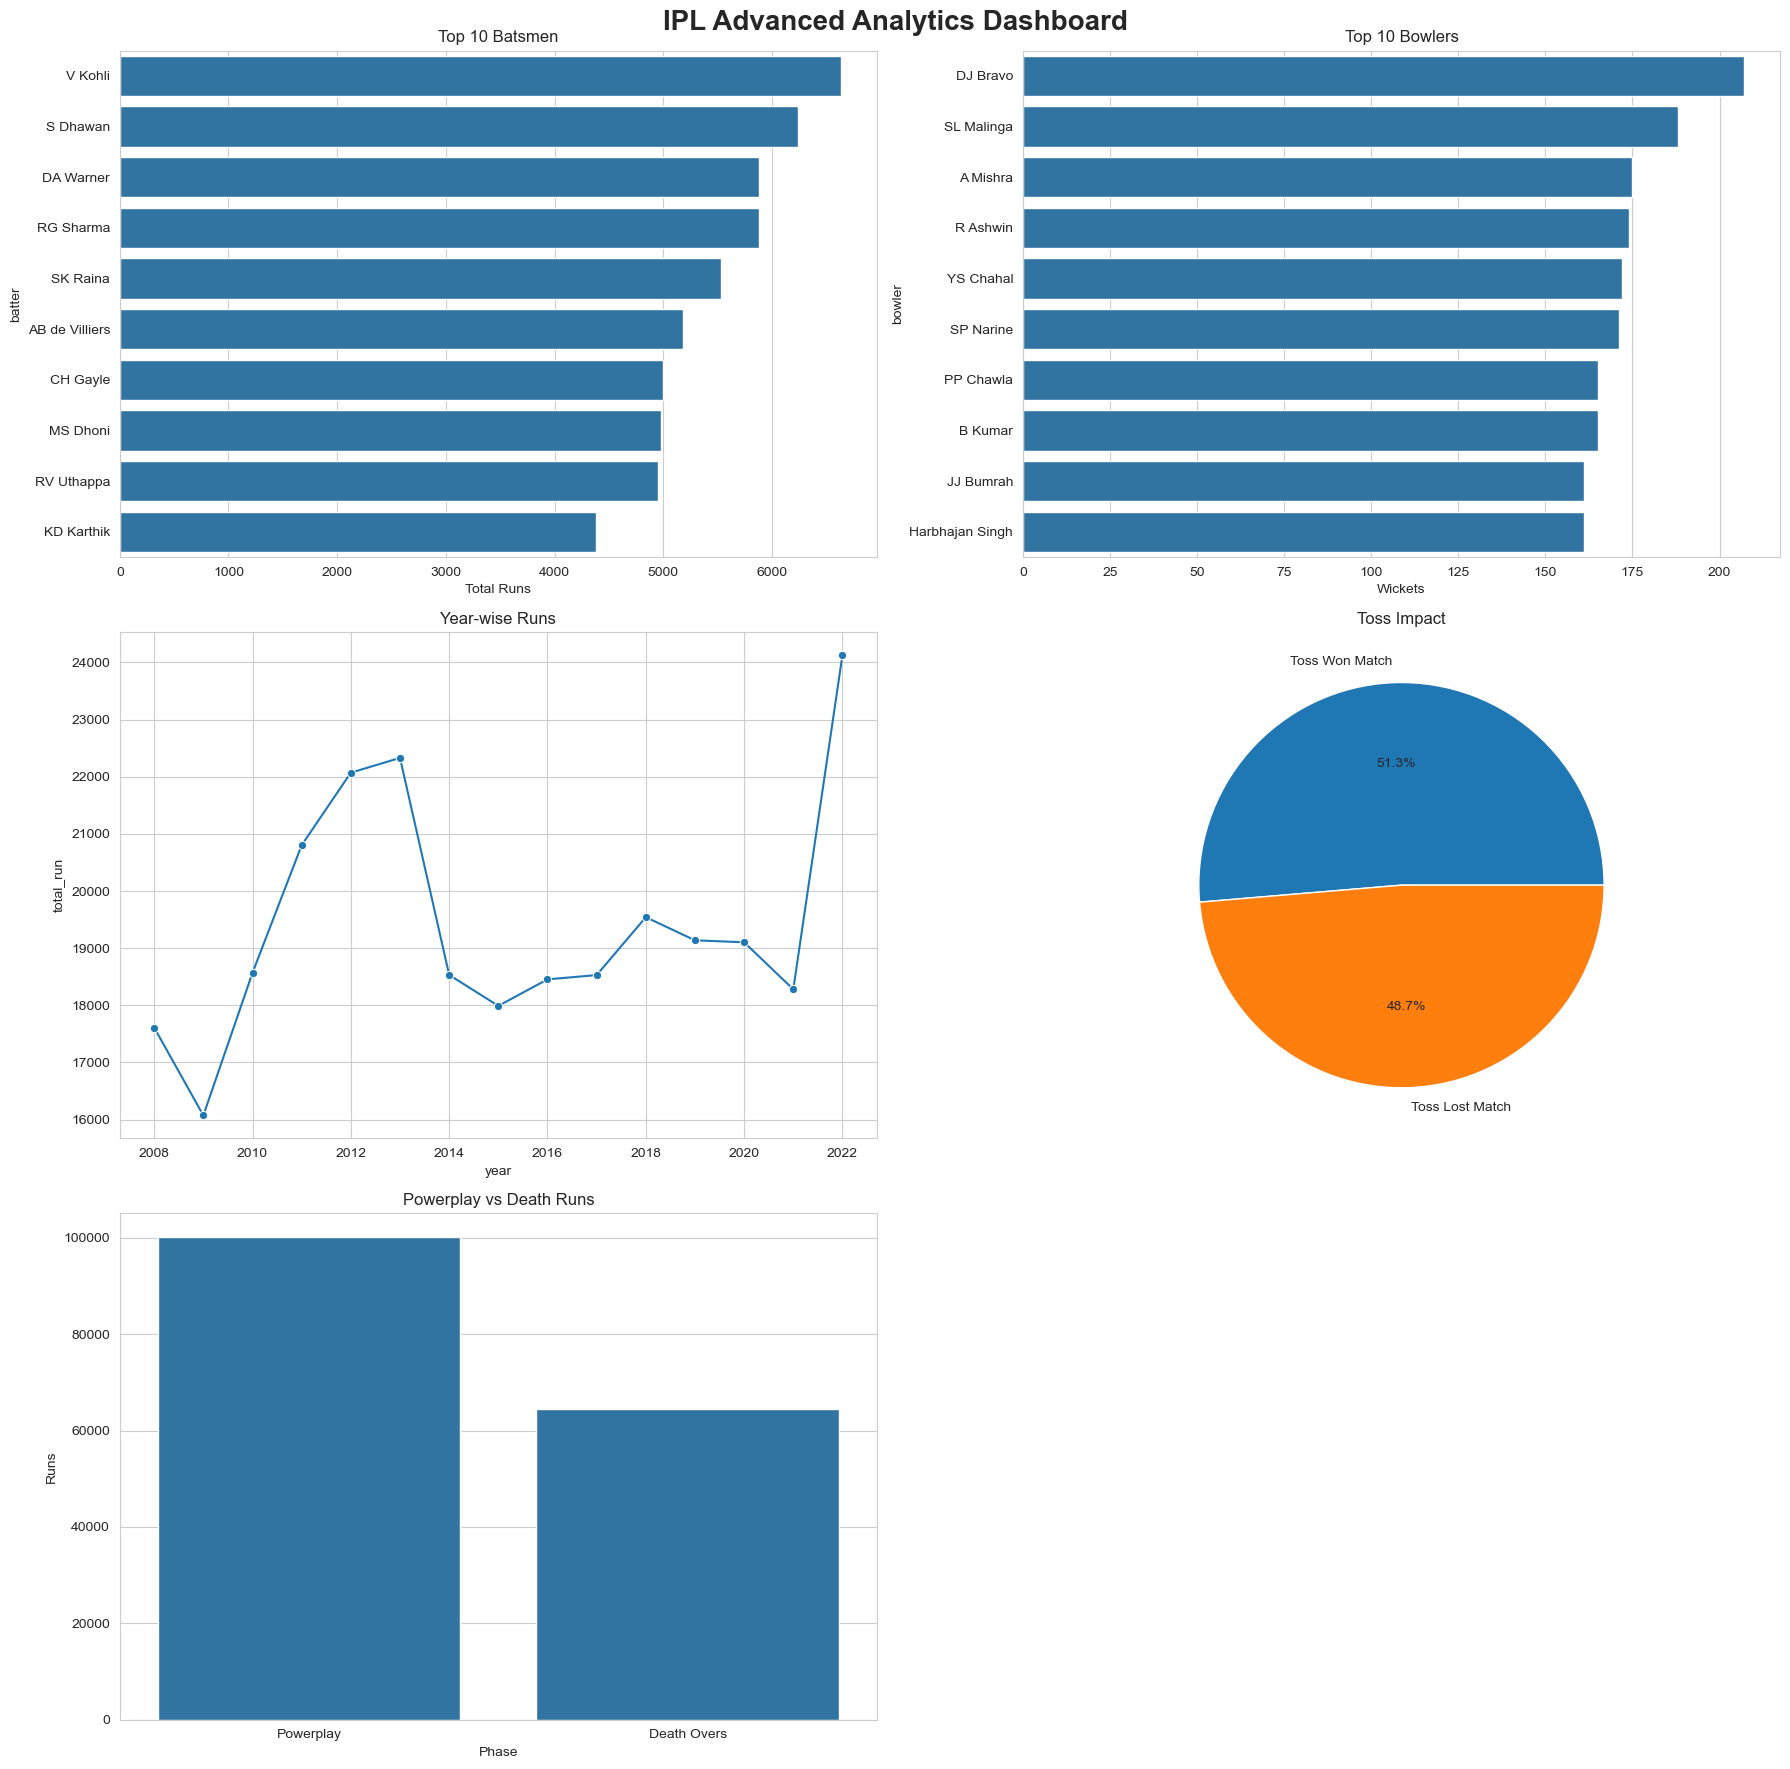

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle("IPL Advanced Analytics Dashboard", fontsize=20, fontweight='bold')

# 1️⃣ Top Batsmen
top_batsmen = deliveries.groupby('batter')['batsman_run'].sum() \
                        .sort_values(ascending=False).head(10)

sns.barplot(x=top_batsmen.values, y=top_batsmen.index, ax=axes[0,0])
axes[0,0].set_title("Top 10 Batsmen")
axes[0,0].set_xlabel("Total Runs")

# 2️⃣ Top Bowlers
top_bowlers = deliveries[deliveries['isWicketDelivery'] == 1] \
                .groupby('bowler')['isWicketDelivery'] \
                .count().sort_values(ascending=False).head(10)

sns.barplot(x=top_bowlers.values, y=top_bowlers.index, ax=axes[0,1])
axes[0,1].set_title("Top 10 Bowlers")
axes[0,1].set_xlabel("Wickets")

# 3️⃣ Year Trend
ipl['year'] = pd.to_datetime(ipl['Date'], errors='coerce').dt.year
yearly_runs = ipl.groupby('year')['total_run'].sum().reset_index()

sns.lineplot(data=yearly_runs, x='year', y='total_run', marker='o', ax=axes[1,0])
axes[1,0].set_title("Year-wise Runs")

# 4️⃣ Toss Impact
toss_success = matches[matches['TossWinner'] == matches['WinningTeam']]
toss_fail = matches[matches['TossWinner'] != matches['WinningTeam']]

axes[1,1].pie(
    [len(toss_success), len(toss_fail)],
    labels=['Toss Won Match', 'Toss Lost Match'],
    autopct='%1.1f%%'
)
axes[1,1].set_title("Toss Impact")

# 5️⃣ Powerplay vs Death
powerplay = deliveries[deliveries['overs'] <= 6]
death = deliveries[deliveries['overs'] >= 16]

comparison = pd.DataFrame({
    'Phase': ['Powerplay', 'Death Overs'],
    'Runs': [powerplay['total_run'].sum(),
             death['total_run'].sum()]
})

sns.barplot(data=comparison, x='Phase', y='Runs', ax=axes[2,0])
axes[2,0].set_title("Powerplay vs Death Runs")

# Hide last empty subplot
axes[2,1].axis('off')

plt.tight_layout()
plt.show()